In [9]:
include("AnalyticResults.jl")
using PyPlot
using JLD2

In [10]:
"""
    naive_powerlaw_fit(data, x; rtol = 1e-2)

For every trace `data[i, j, :]`, assume

    data[i, j, k] ≈ A[i, j] * x[k]^β[i, j]

If the first and last values agree within relative tolerance `rtol`, set
`β[i, j] = 0` and use their average as `A[i, j]`.

Otherwise infer the exponent and prefactor solely from the first and last
points.
"""
function naive_powerlaw_fit(data::AbstractArray{<:Real,3}, x::AbstractVector{<:Real}; rtol = 1e-2)
    a, b, c = size(data)
    length(x) == c || throw(DimensionMismatch("length(x) must equal size(data, 3)"))
    x[1] > 0 && x[end] > 0 || error("x[1] and x[end] must be positive")

    A = fill(NaN, a, b)
    β = fill(NaN, a, b)

    @inbounds for j in 1:b, i in 1:a
        y1 = Float64(data[i, j, 1])
        y2 = Float64(data[i, j, end])

        if !isfinite(y1) || !isfinite(y2) || y1 <= 0 || y2 <= 0
            continue
        end

        # Treat nearly unchanged traces as constant.
        if abs(y2 - y1) ≤ rtol * max(abs(y1), abs(y2))
            β[i, j] = 0.0
            A[i, j] = 0.5 * (y1 + y2)
        else
            β[i, j] = log(y2 / y1) / log(x[end] / x[1])
            A[i, j] = y1 / x[1]^β[i, j]
        end
    end

    return A, β
end

naive_powerlaw_fit

In [11]:
data = load("../plot_data/beta_mc_scan_data.jld2")
Is = data["mc_peak_ifrak"]
Ns = data["Ns"]
g_xis = data["g_xis"]
gbars_gamma = data["gbars_gamma"]
imin = 2
imax = length(Ns)
Is_eff = Is[:,:,imin:imax]
Ns_eff = Ns[imin:imax]

9-element Vector{Int64}:
     33598
    112884
    379269
   1274275
   4281332
  14384499
  48329302
 162377674
 545559478

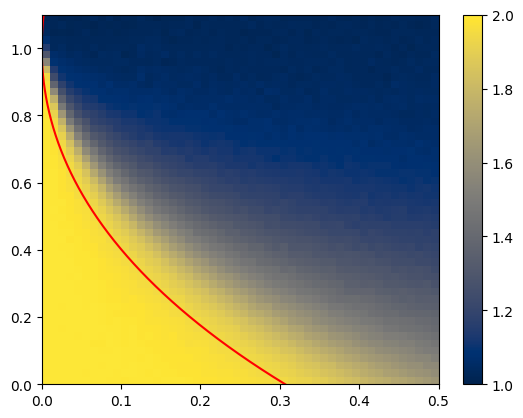

PyObject <matplotlib.colorbar.Colorbar object at 0x150009010>

In [13]:
A, βs =  naive_powerlaw_fit(Is_eff, Ns_eff)
imshow(βs .+ 2.0, origin = "lower", vmin = 1.0, vmax = 2.0, cmap = "cividis", extent = [minimum(gbars_gamma), maximum(gbars_gamma),minimum(g_xis), maximum(g_xis)], aspect = "auto")

g_an = analytic_spont_boundary.(g_xis)
plot(g_an, g_xis, color = "red")

colorbar()

In [14]:
include("PlotSetup.jl")

using JLD2
using PyPlot

data = load("../plot_data/fit_results.jld2")
rs = data["rs"]
gs = data["gs"]
fit_data = data["fit_data"]
fit_data2 = data["fit_data2"]

test_data = copy(fit_data)
test_data[abs.(fit_data2) .> 1e-5] .= 0.0;

# Scaling exponent
function alpha(gxi, gbar)
    val = 1 - analytic_spont_boundary(gxi) / gbar
    if gxi > 1.0
        val = 1.0
    end
    return clamp(val, 0.0, 1.0)
end


alpha (generic function with 1 method)

In [16]:
function beta_valid_plot(ax)

        xcont = LinRange(0,1.7,1000)
    function β(gx,ggbar, x, gg = 0) 
        temp  = 1 .+ (1 .- gx .- gg .- (1 .+ gx .+ gg).*log.(2 ./(1 .+ gx .+ gg)))./ggbar
        #mask1 = temp .< 2
        return temp
    end

    ξfactor = 4
    N = 1E10
    gxcont = xcont
    ggcont = xcont/ξfactor


    tempy = β(gxcont, ggcont,xcont)
    tempy2 = β(gxcont, ggcont,xcont, ggcont ./log(N))
    bdry1 = xcont[argmin(abs.(tempy .- 2))]
    bdry2 = xcont[argmin(abs.(tempy .- 1))]


    cm = 1/2.54
    fs = 8

    xmin,xmax = 0,1.5
    ymin,ymax = 0.8,2.5

    #fig,ax = plt.subplots(figsize = (6*cm,6*cm))
    mask1 = xcont .< bdry1
    mask2 = xcont .> bdry2
    mask = ((xcont .> bdry1) .&& (xcont .< bdry2))
    ax.plot(xcont[mask], tempy[mask], color = "black")
    ax.plot(xcont[mask1], tempy[mask1], color = "black", alpha = 0.5)
    ax.plot(xcont[mask2], tempy[mask2], color = "black", alpha = 0.5)
    ax.set_ylim(ymin,ymax)
    ax.set_xlim(xmin,xmax)
    ax.set_yticks(1.0:0.5:2.0)
    #ax.vlines([bdry1, bdry2], 0.5,2.5)
    ax.plot([0,bdry1],[2,2], ls = "--", color = "black")
    ax.plot([bdry2,2],[1,1], ls = "--", color = "black")
    ax.text(0.6,2.2,"valid")
    #ax.text(0.1,2.2,R"not \\ valid", fontsize = fs)
    #ax.text(1.05,2.2,"not valid", fontsize = fs)
    ax.set_ylabel(R"$\beta (g_\xi,\bar{g}_\gamma)$")
    ax.set_xlabel(R"$g_\xi;\;,\bar{g}_\gamma =g_\xi/4$")
    #ax.plot([bdry1,bdry1], [ymin,ymax], ls = "--", color = "black",lw = 2.5)
    #ax.plot([bdry2,bdry2], [ymin,ymax], ls = "--", color = "white", lw = 2.5)
    #println(tempx[1])
    #println(tempx[argmin(abs.(tempy .- 1))])L
    #println(maximum())
    ax.fill_between([0,bdry1], [ymin,ymin],[ymax,ymax], color = "red",alpha = 0.2)
    ax.fill_between([bdry1,bdry2], [ymin,ymin],[ymax,ymax], color = "green",alpha = 0.2)
    ax.fill_between([bdry2,xmax], [ymin,ymin],[ymax,ymax], color = "red",alpha = 0.2)
    #plt.savefig("figS2.pdf", bbox_inches = "tight")
end


beta_valid_plot (generic function with 1 method)

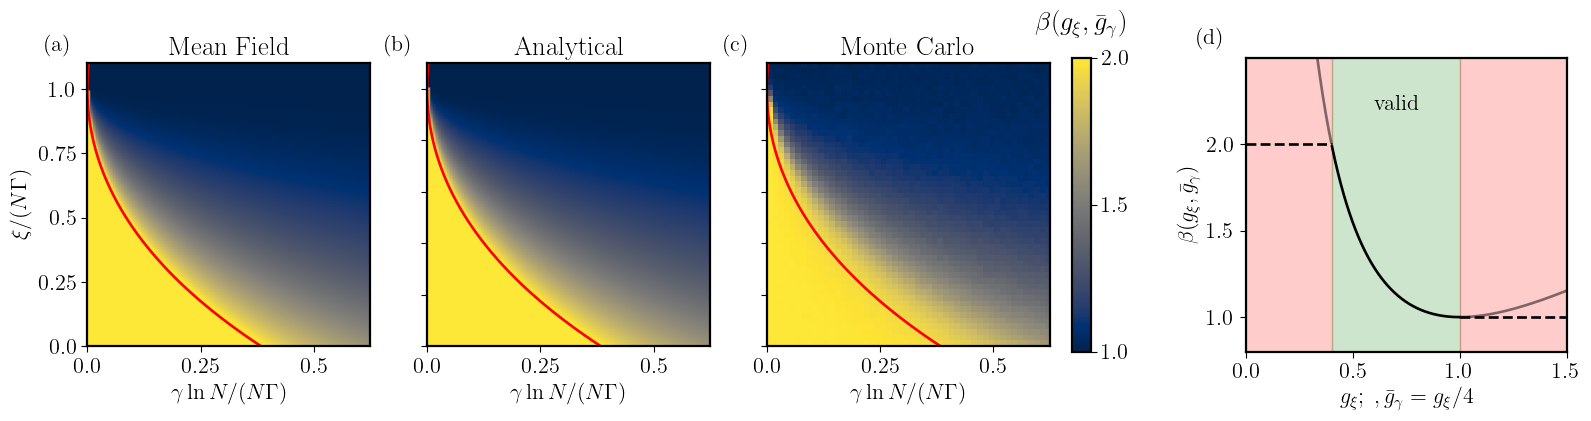

: 

In [ ]:
w, h = latex_plot_setup(scale = 2.0, ratio = 0.8, font_size_pt = 8)
fig, axes = subplots(ncols = 4, figsize = (4 * w, h))
im = axes[1].imshow(test_data, origin = "lower", extent = [first(gs), last(gs), first(rs), last(rs)], cmap = "cividis", aspect = "auto", zorder = 1)
sca(axes[1])
plot(g_an, g_xis, color = "red")
gca().set_xlabel(L"\gamma\ln N/(N\Gamma)")
gca().set_ylabel(L"\xi/(N\Gamma)")
gca().set_title("Mean Field")

an_data = [alpha(gxi, gbar) for gxi in rs, gbar in gs]
im = axes[2].imshow(2.0 .- an_data, origin = "lower", extent = [first(gs), last(gs), first(rs), last(rs)], cmap = "cividis", aspect = "auto")
sca(axes[2])
plot(g_an, g_xis, color = "red")
gca().set_xlabel(L"\gamma\ln N/(N\Gamma)")
gca().set_title("Analytical")

sca(axes[3])
imshow(βs .+ 2.0, origin = "lower", vmin = 1.0, vmax = 2.0, cmap = "cividis", extent = [minimum(gbars_gamma), maximum(gbars_gamma),minimum(g_xis), maximum(g_xis)], aspect = "auto")


g_an = analytic_spont_boundary.(g_xis)
plot(g_an, g_xis, color = "red")
gca().set_title("Monte Carlo")
gca().set_xlabel(L"\gamma\ln N/(N\Gamma)")
clb = fig.colorbar(im, ax=axes[1:3], location="right", fraction=0.1, pad=0.02, aspect = 15)

axes[1].set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])

axes[1].set_xticklabels([0.0, 0.25, 0.5])
axes[1].set_yticklabels([0.0, 0.25, 0.5, 0.75, 1.0])
axes[2].set_xticklabels([0.0, 0.25, 0.5])
axes[3].set_xticklabels([0.0, 0.25, 0.5])
clb.set_ticks([1.0, 1.5, 2.0])
clb.ax.set_title(L"\beta(g_\xi,\bar g_\gamma)", pad = 20)
axes[1].text(-0.15, 1.1, "(a)", transform = axes[1].transAxes, va = "top")
axes[2].text(-0.15, 1.1, "(b)", transform = axes[2].transAxes, va = "top")
axes[3].text(-0.15, 1.1, "(c)", transform = axes[3].transAxes, va = "top")
axes[4].text(-0.15, 1.1, "(d)", transform = axes[4].transAxes, va = "top")
#axes[2].sharey(axes[1])
#axes[3].sharey(axes[1])
axes[2].set_yticklabels([])
axes[3].set_yticklabels([])
axes[1].set_box_aspect(1)
axes[2].set_box_aspect(1)
axes[3].set_box_aspect(1)

beta_valid_plot(axes[4])

savefig("../data/figS1.pdf", bbox_inches = "tight")